# Universal Language model fine-tuning for text classification


Transfer learning is a technique in which knowledge gained through a prior task or dataset is used to improve performance on another.

In computer vision, transfer learning became highly effective thanks to large-scale datasets like ImageNet, MS-COCO, and KITTI. But in natural language processing (NLP), transfer learning had lagged behind. Early attempts required task-specific architectures, retraining from scratch, or large in-domain corpora. These approaches often led to overfitting on small datasets and catastrophic forgetting when fine-tuning.

Most prior work had focused on transductive transfer, where the source and target tasks are the same but the datasets differ. In contrast, inductive transfer—where the source and target tasks differ—had been less successful in NLP, largely because of the challenges mentioned above.

- **transductive transfer** : When source and target tasks are the same but the domains (datasets) are different.

- **inductive transfer** : When source and target tasks are different regardless of the source or target domain. Multi-task learning (simultaneously learning two tasks) can also be considered a form of inductive learning.
[source](https://www.ibm.com/think/topics/transfer-learning)

ULMFit(Universal Language Model Fine-tuning), proposed by Jeremy Howard and Sebastian Ruder, addresses these concerns and enables robust transfer learning for any NLP tasks, hence reducing the error by 18 to 24%.

The method consists of three stages:
1. Training the language model (LM) on a general-domain corpus to capture general features of the language in different layers. Such features captured by the language modelling include but are not limited to: hierarchical relations, sentiment, long-term dependencies...etc. This stage only needs to be performed once and improves results and convergence of downstream model.
2. Fine-tune the LM on target data to adapt the LM to the specificities of said data. This is achieved through discriminative fine-tuning and slanted triangular learning rates.
3. Fine-tune the classifier (downstream task). At this point the initial LM is augmented with two additional linear blocks that will be trained from scratch. The first layer of the linear block takes as input the concat pooled last hidden layer states. For fine-tuning, besides STLR and discriminative fine-tuning, gradual unfreezing is also used to avoid forgetting.


[Paper](https://arxiv.org/abs/1801.06146)




# Self-supervised learning


In many deep learning applications, we start with a pre-trained model — one that already has useful prior knowledge — and then fine-tune it for a specific task.

But in some domains, pre-trained models are hard to come by. In such cases, a practical alternative is self-supervised learning: instead of relying on external labels, we create labels directly from the input data itself. The model is first trained on such a task to capture general patterns in the data, which can then help when fine-tuning on the actual target task.

This setup introduces two kinds of tasks:

- **Pretext task**: the auxiliary task used for pretraining.

- **Downstream task**: the main task the model is ultimately fine-tuned for.

A good pretext task should be:

- Relatively fast and easy to compute

- Something a human could also plausibly attempt

- Most importantly, aligned so that solving it provides insights useful for the downstream task

Once we have a satisfying pre-trained model, it is important to treat it during fine-tuning in a way that won't deteriorate the pre-training.

Processes to consider for that are:
- Gradual unfreezing
- discriminative learning rates
- One-cycle training

Another useful trick is to introduce a constrastive loss.

The contrastive loss penalizes getting different predictions for different versions of the same data. If we took an image and transformed it (rotation, cropping, removing patches) then the model should give the same answer for the original image and the transformed one.

[Article](https://www.fast.ai/posts/2020-01-13-self_supervised.html)

# Text pre-processing

Text pre-processing in NLP is conceptually similar to handling categorical variables in tabular data, but with the added complexity of sequences. Each step prepares raw text so it can be modeled effectively.

## Tokenization
Tokenization converts the text into a long sequence of words, subwords or characters. These words are referred to as *tokens*.

The three main approaches are:
* Word-based
* Subword based
* Character-based

Each method has trade-offs, as each language has its subtilities. Some of the Concerns they need be addressed are: ponctuation, composed words, hyphened words, etc.

## Numericalization

Nest, we make a list of all unique tokens that appear in the training set to construct what we refer to as *vocab*. Each token is then replaced with its index in the vocab.

It is critical to handle out-of-vocabulary (OOV) tokens.

## Batching for Language Modeling

Similarly to mini-batch in vision tasks, text processing requires to group tokens into tensors and then stack them efficiently. Unlike images, though, ordering matters. This means that each new batch begins where the previous one ended. Additionnaly, text cannot be simply resized to a fixed length as some data can be lost in the process.

# AWD-LSTM Architecture

In chapter 10 of Fastai's Practical Deep Learning book, the authors walk through training a text classifier on the IMDb sentiment dataset using the AWD-LSTM architecture — the same one used for the ULMFiT paper.

[AWD-LSTM](https://arxiv.org/pdf/1708.02182), short for ASGD Weight-Dropped LSTM, is a variant of RNN that combines two techniques: Weight Dropping regularization and Averaged Stochastic Gradient Descent optimization.

But to understand this architecture, we need to first look at some of its underlying concepts.

RNNs (Recurrent Neural Networks) are called recurrent because they perform the same process for every element of a sequence, with the output being dependent on previous computations. They are particularly useful in NLP tasks because they can model sequential information.

A typical RNN looks like this ([source](https://arxiv.org/pdf/1912.05911)):

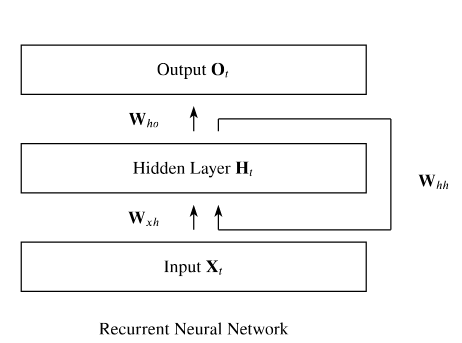


However, traditional RNNs suffer from the vanishing gradient problem, where the influence of a given input on the network's output decreases exponentially over time, hindering learning of long-term dependencies.

That's where LSTM come into play. Unlike vanilla RNNs, whose repeating module consist of only a single layer such as a `tanh` layer, LSTM's repeating module has four components: a forgotten gate, input gate, output gate and cell state.
* **Forget Gate** : Controls whether to forget hidden state information from the previous layer with a certain probability.
* **Input Gate** : Used to store information of the current sequence position.
* **Output Gate** : Decides what we are going to output. Determined by two parts. The first part is the sigmoid(cell), which is obtained from the hidden state h(t−1) of the previous sequence, the data X(t) of the sequence, and the activation function sigmoid. The second part consists of the hidden state C(t) and the tanh activation function.
* **Cell State** : stores the result of both the Forget gate and the Input gate.

[source](https://colah.github.io/posts/2015-08-Understanding-LSTMs/).

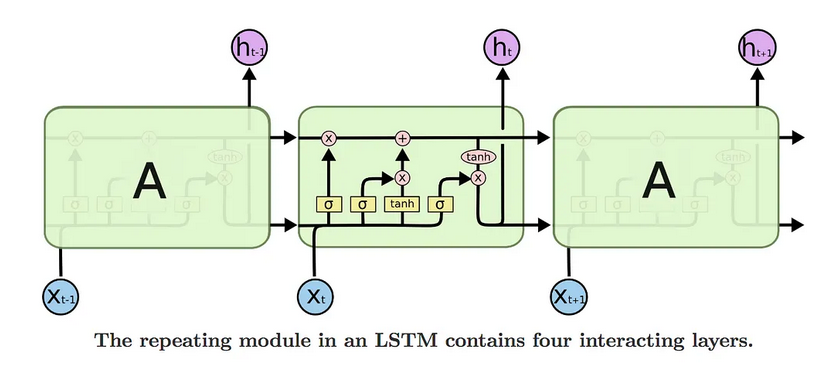

Finally, the AWD-LSTM architecture introduces weight-dropping, a novel regularization technique applied to the recurrent weights of the LSTM cells to prevent overfitting. Additionally, it uses averaged SGD, which considers weights from previous iterations and returns an averaged value for more stable training.

# Training a text classifier

In [ ]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()
from fastbook import *
from IPython.display import display,HTML

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 87.7 MB/s eta 0:00:00
Mounted at /content/gdrive


## Character tokenization

The most common tokenization method used as of 2025 remains the whitespace (word-based) tokenization.

In this section however, I will be implementing the character tokenization since it's the only tokenization method not shown in the chapter.

In [ ]:
from fastai.text.all import *
path = untar_data(URLs.IMDB)
print(path.ls())

[Path('/root/.fastai/data/imdb/imdb.vocab'), Path('/root/.fastai/data/imdb/train'), Path('/root/.fastai/data/imdb/unsup'), Path('/root/.fastai/data/imdb/README'), Path('/root/.fastai/data/imdb/tmp_lm'), Path('/root/.fastai/data/imdb/tmp_clas'), Path('/root/.fastai/data/imdb/test')]


I only need the train, text and unsup folders.

In [ ]:
files = get_text_files(path, folders = ['train', 'test', 'unsup'])

Here is a sample review:

In [ ]:
txt = files[0].open().read(); txt[:75]

'this movie was fantastic great movie all through scary as hell. and i mean '

In [ ]:
# Building upon BaseTokenizer ensures we keep the special rules
class CharTokenizer(BaseTokenizer):
  def __init__(self, **kwargs): super().__init__(split_char=None, **kwargs)
  def __call__(self, items):
        # Convert each string to a list of characters
        # Return a generator type to be compatible with TextBlock
        return ([(char if char != " " else "▁") for char in str(t)] for t in items)

Time to take a look at a sample result.

In [ ]:
charTknzer = CharTokenizer()
toks = first(charTknzer([txt]))
print(coll_repr(toks, 30))

(#823) ['t','h','i','s','▁','m','o','v','i','e','▁','w','a','s','▁','f','a','n','t','a','s','t','i','c','▁','g','r','e','a','t'...]


## Email tagging

For this task, and following the steps described in chapter 10, I will train an email spam tagger.

Taking the AWD LSTM model that was initially trained on wikitext, the first step is to fine tune it on my dataset for text generation/completion.


### Retrieving a text corpus

As I didn't compile a personalised dataset, I will take a publicly available and annotated dataset for email tagging.

Conveniently, there is already the Enron email dataset which is a compilation of 50 000 emails generated by the employees of the Enron Corporation.


In [ ]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
from email import policy, parser
import re
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download latest version
url_base = 'http://www.aueb.gr/users/ion/data/enron-spam/preprocessed/'
url = "https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.zip"
zip_path = "enron_spam_data.zip"
csv_path = "enron_spam_data.csv"

# Check if already exists
if os.path.exists(csv_path):
    print(f"Dataset already exists at {csv_path}")
else:

  print("Downloading Enron-Spam dataset...")
  response = requests.get(url)
  response.raise_for_status()

  # Extract the zip file
  with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
      zip_file.extractall(".")

  print(f"Dataset downloaded and extracted to {csv_path}")

Dataset downloaded and extracted to enron_spam_data.csv


In [ ]:
raw_df = pd.read_csv(csv_path)
raw_df.head()

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger block a - 1 # 2 commenced on\nsaturday at 2 : 00 p . m . at about 6 , 500 gross . carlos expects between 9 , 500 and\n10 , 000 gross for tomorrow . vastar owns 68 % of the gross production .\ngeorge x 3 - 6992\n- - - - - - - - - - - - - - - - - - - - - - forwarded by george weissman / hou / ect on 12 / 13 / 99 10 : 16\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\ndaren j farmer\n12 / 10 / 99 10 : 38 am\nto : carlos j rodriguez / hou / ect @ ect\ncc : george weissman / hou / ect @ ect , melissa graves / hou / ect @ ect\nsubject : va...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,"fyi - see note below - already done .\nstella\n- - - - - - - - - - - - - - - - - - - - - - forwarded by stella l morris / hou / ect on 12 / 14 / 99 10 : 18\nam - - - - - - - - - - - - - - - - - - - - - - - - - - -\nfrom : sherlyn schumack on 12 / 14 / 99 10 : 06 am\nto : stella l morris / hou / ect @ ect\ncc : howard b camp / hou / ect @ ect\nsubject : re : issue\nstella ,\nthis has already been taken care of . you did this for me yesterday .\nthanks .\nhoward b camp\n12 / 14 / 99 09 : 10 am\nto : stella l morris / hou / ect @ ect\ncc : sherlyn schumack / hou / ect @ ect , howard b camp / ...",ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by lauri a allen / hou / ect on 12 / 14 / 99 12 : 17\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nkimberly vaughn\n12 / 10 / 99 02 : 54 pm\nto : lauri a allen / hou / ect @ ect\ncc : mary m smith / hou / ect @ ect\nsubject : meter 7268 nov allocation\nlauri . . i have put this on strangas gas until i can get a contract from\ndaren .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by kimberly vaughn / hou / ect on 12 / 10 / 99 01 : 52\npm - - - - - - - - - - - - - - - - - - - - - - - - - - -\nlauri a allen\n12...,ham,1999-12-14


As can be seen, the dataset as is is rough looking.

The text column contains header + body as well as footer, so this needs to be properly cleaned and re-shaped.

Let's take a look at some basic info on this dataset:

In [ ]:
print("------ Dataset Overview ------\n")
print(f"Total emails: {len(raw_df)}\n")
print(f"Raw dataset Columns: {raw_df.columns}\n")
print("Missing values")
print("=" * 30)

missing = raw_df.isnull().sum()
for col, miss_count in missing.items():
    if miss_count > 0:
        percentage = (miss_count / len(raw_df)) * 100
        print(f"{col}: {miss_count:,} ({percentage:.1f}%)")

print("\nEmail category distribution")
class_counts = raw_df['Spam/Ham'].value_counts()
for class_name, count in class_counts.items():
    percentage = (count / len(raw_df)) * 100
    print(f"{class_name}: {count:,} ({percentage:.1f}%)")

------ Dataset Overview ------

Total emails: 33716

Raw dataset Columns: Index(['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date'], dtype='object')

Missing values
Subject: 289 (0.9%)
Message: 371 (1.1%)

Email category distribution
spam: 17,171 (50.9%)
ham: 16,545 (49.1%)


### Data cleaning

In [ ]:
import io
from email.parser import Parser
from email import policy
import re
import warnings
warnings.filterwarnings('ignore')

def extract_email_body(message_text):
    """Extract clean email body using email parser"""
    if pd.isna(message_text) or not isinstance(message_text, str):
        return ""

    try:
        # Parse email using email library
        parser = Parser(policy=policy.default)
        email_msg = parser.parsestr(message_text)

        # Extract body text
        if email_msg.is_multipart():
            body = ""
            for part in email_msg.walk():
                if part.get_content_type() == "text/plain":
                    try:
                        body = part.get_payload(decode=True).decode('utf-8', errors='ignore')
                    except:
                        body = str(part.get_payload())
                    break
        else:
            try:
                if email_msg.get_content_type() == "text/plain":
                    body = email_msg.get_payload(decode=True).decode('utf-8', errors='ignore')
                else:
                    body = str(email_msg.get_payload())
            except:
                body = str(email_msg)

    except Exception:
        # Fallback to original message
        body = message_text

    # Clean the body text
    if isinstance(body, str):
        # Remove email headers
        body = re.sub(r'^(From|To|Subject|Date|CC|BCC):.*\n', '', body, flags=re.MULTILINE | re.IGNORECASE)
        # Remove forwarded message markers
        body = re.sub(r'-----Original Message-----.*', '', body, flags=re.DOTALL)
        body = re.sub(r'________________________________.*', '', body, flags=re.DOTALL)
        # Clean whitespace
        body = re.sub(r'\s+', ' ', body).strip()

    return body if body else ""

def preprocess(row):
    """Extract and clean text for ULMFiT training"""
    # Get subject and message
    subject = str(row['Subject']) if pd.notna(row['Subject']) else ""
    message = str(row['Message']) if pd.notna(row['Message']) else ""

    # Extract clean body
    clean_body = extract_email_body(message)

    # Combine subject and body
    combined_text = f"{subject} {clean_body}".strip()

    # Final cleaning for language model
    combined_text = re.sub(r'\s+', ' ', combined_text)

    return pd.Series({
        'text': combined_text,
        'label': row['Spam/Ham'],
        'is_spam': 1 if row['Spam/Ham'] == 'spam' else 0
    })

# Usage: apply on your dataframe
parsed_df = raw_df.apply(preprocess, axis=1)

In [ ]:
parsed_df.head()

,text,label,is_spam
0,christmas tree farm pictures,ham,0
1,"vastar resources , inc . gary , production from the high island larger block a - 1 # 2 commenced on saturday at 2 : 00 p . m . at about 6 , 500 gross . carlos expects between 9 , 500 and 10 , 000 gross for tomorrow . vastar owns 68 % of the gross production . george x 3 - 6992 - - - - - - - - - - - - - - - - - - - - - - forwarded by george weissman / hou / ect on 12 / 13 / 99 10 : 16 am - - - - - - - - - - - - - - - - - - - - - - - - - - - daren j farmer 12 / 10 / 99 10 : 38 am to : carlos j rodriguez / hou / ect @ ect cc : george weissman / hou / ect @ ect , melissa graves / hou / ect @ e...",ham,0
2,calpine daily gas nomination - calpine daily gas nomination 1 . doc,ham,0
3,"re : issue fyi - see note below - already done . stella - - - - - - - - - - - - - - - - - - - - - - forwarded by stella l morris / hou / ect on 12 / 14 / 99 10 : 18 am - - - - - - - - - - - - - - - - - - - - - - - - - - - from : sherlyn schumack on 12 / 14 / 99 10 : 06 am to : stella l morris / hou / ect @ ect cc : howard b camp / hou / ect @ ect subject : re : issue stella , this has already been taken care of . you did this for me yesterday . thanks . howard b camp 12 / 14 / 99 09 : 10 am to : stella l morris / hou / ect @ ect cc : sherlyn schumack / hou / ect @ ect , howard b camp / hou...",ham,0
4,meter 7268 nov allocation fyi . - - - - - - - - - - - - - - - - - - - - - - forwarded by lauri a allen / hou / ect on 12 / 14 / 99 12 : 17 pm - - - - - - - - - - - - - - - - - - - - - - - - - - - kimberly vaughn 12 / 10 / 99 02 : 54 pm to : lauri a allen / hou / ect @ ect cc : mary m smith / hou / ect @ ect subject : meter 7268 nov allocation lauri . . i have put this on strangas gas until i can get a contract from daren . - - - - - - - - - - - - - - - - - - - - - - forwarded by kimberly vaughn / hou / ect on 12 / 10 / 99 01 : 52 pm - - - - - - - - - - - - - - - - - - - - - - - - - - - lau...,ham,0


## EDA

Text(0.5, 1.0, 'Spam vs Ham Distribution')

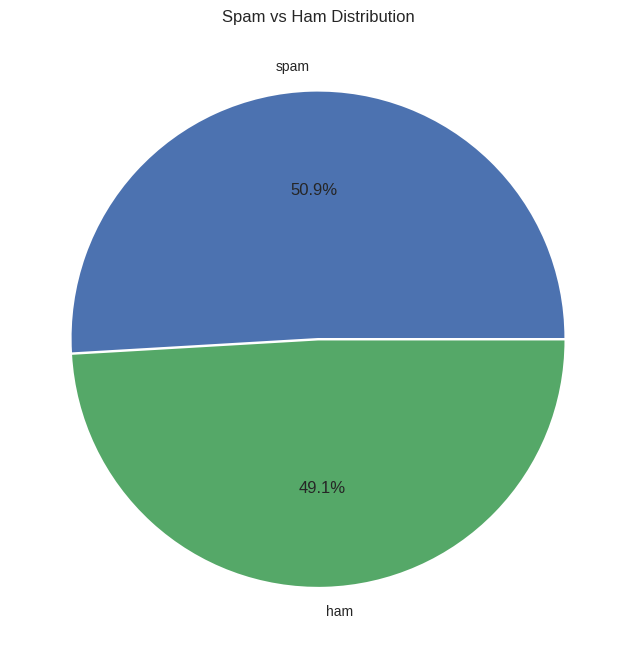

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8' if 'seaborn-v0_8' in plt.style.available else 'default')
# Create a figure with a white background
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('white')

# 1. Label distribution
label_counts = parsed_df['label'].value_counts()
ax.pie(class_counts.values, labels=label_counts.index, autopct='%1.1f%%', explode=(0, 0.01))
ax.set_title('Spam vs Ham Distribution')

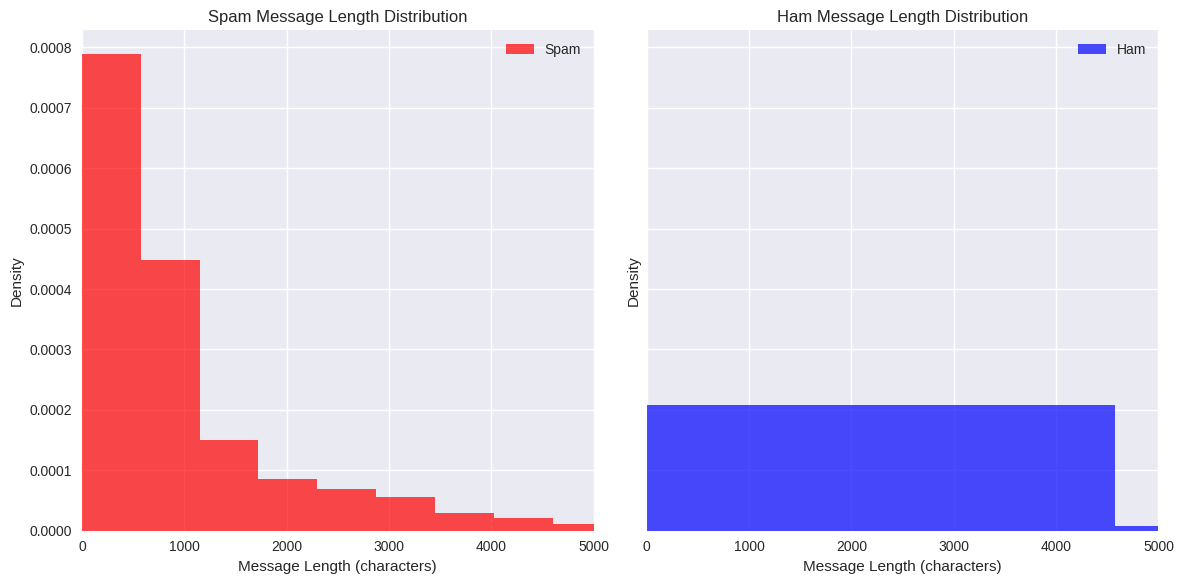

In [ ]:
# 2. Message length distribution per label
parsed_df['text_length'] = parsed_df['text'].str.len()
spam_msg_length = parsed_df[parsed_df["label"]=="spam"]["text_length"]
ham_msg_length = parsed_df[parsed_df["label"]=="ham"]["text_length"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].hist(spam_msg_length, bins=50, alpha=0.7, label='Spam', color='red', density=True)
axes[0].set_xlabel('Message Length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Spam Message Length Distribution')
axes[0].legend()
axes[0].set_xlim(0, 5000)

axes[1].hist(ham_msg_length, bins=50, alpha=0.7, label='Ham', color='blue', density=True)
axes[1].set_xlabel('Message Length (characters)')
axes[1].set_ylabel('Density')
axes[1].set_title('Ham Message Length Distribution')
axes[1].legend()
axes[1].set_xlim(0, 5000)

plt.tight_layout()

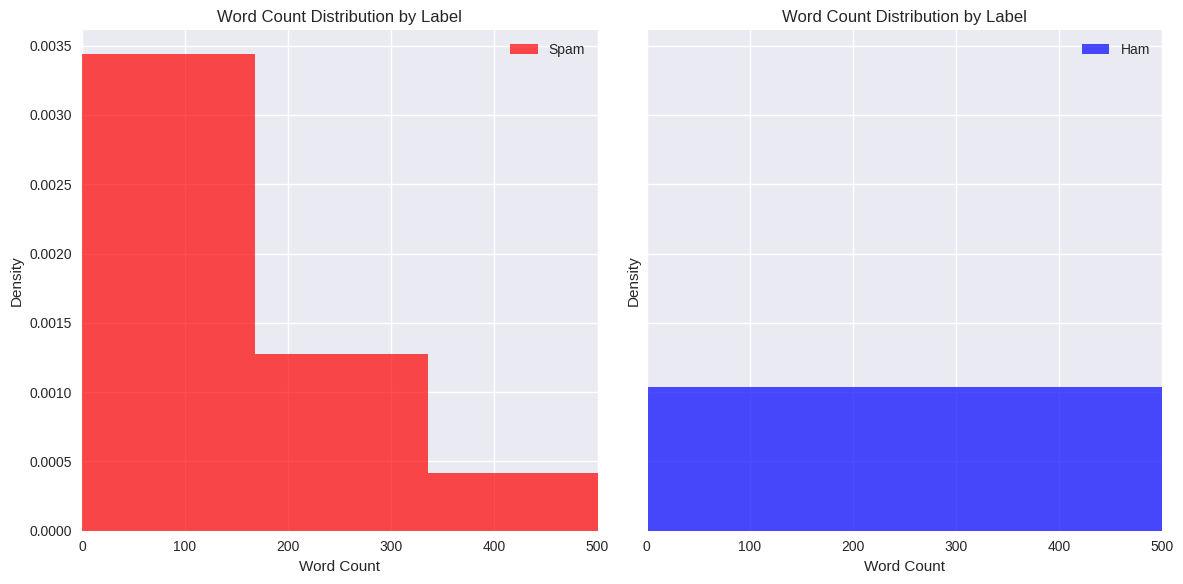

In [ ]:
# 3. word count distribution per label
parsed_df['word_count'] = parsed_df['text'].str.split().str.len()
spam_words = parsed_df[parsed_df['label'] == 'spam']['word_count']
ham_words = parsed_df[parsed_df['label'] == 'ham']['word_count']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].hist(spam_words, bins=50, alpha=0.7, label='Spam', color='red', density=True)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Density')
axes[0].set_title('Word Count Distribution by Label')
axes[0].legend()
axes[0].set_xlim(0, 500)

axes[1].hist(ham_words, bins=50, alpha=0.7, label='Ham', color='blue', density=True)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].set_title('Word Count Distribution by Label')
axes[1].legend()
axes[1].set_xlim(0, 500)

plt.tight_layout()

In [ ]:
!pip install wordcloud

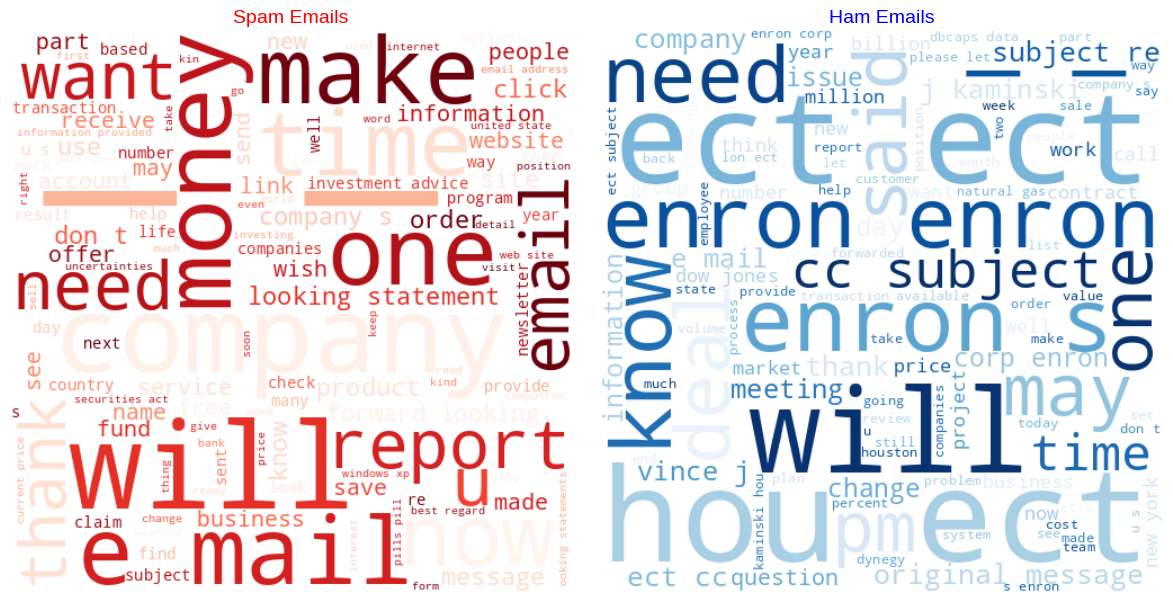

In [ ]:
# Importing WordCloud for text visualization
from wordcloud import WordCloud

# Create separate WordCloud objects for each category
spam_wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white', colormap='Reds')
ham_wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white', colormap='Blues')

# Generate word clouds
spam_text = parsed_df[parsed_df["label"] == "spam"]["text"].str.cat(sep=" ")
ham_text = parsed_df[parsed_df["label"] == "ham"]["text"].str.cat(sep=" ")

spam_wc = spam_wc.generate(spam_text)
ham_wc = ham_wc.generate(ham_text)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].set_title('Spam Emails', fontsize=14, color='red')
axes[0].axis('off')

axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].set_title('Ham Emails', fontsize=14, color='blue')
axes[1].axis('off')

plt.tight_layout()

In [ ]:
parsed_df.head(2)

,text,label,is_spam,text_length,word_count
0,christmas tree farm pictures,ham,0,28,4
1,"vastar resources , inc . gary , production from the high island larger block a - 1 # 2 commenced on saturday at 2 : 00 p . m . at about 6 , 500 gross . carlos expects between 9 , 500 and 10 , 000 gross for tomorrow . vastar owns 68 % of the gross production . george x 3 - 6992 - - - - - - - - - - - - - - - - - - - - - - forwarded by george weissman / hou / ect on 12 / 13 / 99 10 : 16 am - - - - - - - - - - - - - - - - - - - - - - - - - - - daren j farmer 12 / 10 / 99 10 : 38 am to : carlos j rodriguez / hou / ect @ ect cc : george weissman / hou / ect @ ect , melissa graves / hou / ect @ e...",ham,0,4307,1577


## Language Model Fine-tuning

Creating the language model dataloader and fine tuning.

In [ ]:
# Build LM DataLoaders from CSV
dls_lm = TextDataLoaders.from_df(
    parsed_df,
    text_col="text",    # The first column
    valid_pct=0.1,
    is_lm=True,
    bs=64,
    seq_len=72
)

dls_lm.show_batch(max_n=2, trunc=80, decode=True)

xxbos good year hey friend - i feel great v ' 1 . c ^ 0 - d _ 1 * n 750 m ' gg 3 o p ! | ls 169 . 00 get info same day shlpp 1 ng to enough nice meeting you xxunk ashley xxunk xxunk corporation co . , ltd . , xxunk , xxunk xxunk , thailand phone : 295 - 767 - xxunk mobile
declined in the wake of a securities and exchange commission investigation into the partnerships , the people said . the boards of the three companies were meeting today on the proposed transaction , the people said . dynegy and enron , rival houston energy trading firms , haven ' t agreed on a price , the people said . dynegy is proposing a stock swap with a modest premium while enron is
good year hey friend - i feel great v ' 1 . c ^ 0 - d _ 1 * n 750 m ' gg 3 o p ! | ls 169 . 00 get info same day shlpp 1 ng to enough nice meeting you xxunk ashley xxunk xxunk corporation co . , ltd . , xxunk , xxunk xxunk , thailand phone : 295 - 767 - xxunk mobile :
in the wake of a securities and exchange commission investigation 

In [ ]:
import torch
from torch.serialization import safe_globals

learn_lm = language_model_learner(
    dls_lm, AWD_LSTM, drop_mult=0.3,
    metrics=[accuracy, Perplexity()]).to_fp16()

learn_lm.fit_one_cycle(5, 2e-3)

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.251417,4.121452,0.341704,61.648682,09:03
1,3.806872,3.654716,0.394010,38.656532,09:08
2,3.632579,3.505830,0.412135,33.309063,09:14
3,3.458884,3.449570,0.418993,31.486864,08:55
4,3.430539,3.441118,0.420418,31.221859,08:58


In [ ]:
# Saving fine-tuned model
learn_lm.save_encoder('fine_tuned_lm')

## Classifier training

In [ ]:
from sklearn.model_selection import train_test_split
# Create train/val/test splits
train_val, test = train_test_split(
    parsed_df, test_size=0.2, stratify=parsed_df['label'], random_state=42
)

train, val = train_test_split(
    train_val, test_size=0.2/(1-0.2),
    stratify=train_val['label'], random_state=42
)
train['is_valid'] = False
val['is_valid'] = True

dls_clas = TextDataLoaders.from_df(
        pd.concat([train, val]),
        text_col='text',
        label_col='label',
        vocab=dls_lm.vocab,              # Use same vocab as LM
        text_vocab=dls_lm.vocab,
        is_lm=False,              # This is for classification
        valid_col='is_valid',     # We'll create this column
        bs=64,
        seq_len=72
    )

dls_clas.show_batch(max_n=3)

,text,category
0,"xxbos enron mentions enron : a wake - up call the wall street journal , 12 / 04 / 01 fall of a power giant : dynegy hits back at enron with lawsuit - - - claim is that failed merger entitles concern to get northern natural gas the wall street journal , 12 / 04 / 01 enron secures $ 1 . 5 billion in new financing - - - j . p . morgan , citigroup pact is first step ; now , lifeline is sought for trading unit the wall street journal , 12 / 04 / 01 fall of a power giant : burst of chapter 11 filings marks big year for the bankruptcy bar the wall street journal , 12 / 04 / 01 fall of a power giant : now is the time for creditors to vie against each other the wall street journal",ham
1,"xxbos enron mentions usa : some fault rating agencies on enron debacle . reuters english news service , 11 / 28 / 01 usa : update 1 - enron names two to new litigation committee . reuters english news service , 11 / 28 / 01 usa : enron hires blackstone for corporate advice - source . reuters english news service , 11 / 28 / 01 usa : metals traders lament loss of enrononline liquidity . reuters english news service , 11 / 28 / 01 usa : u . s . stocks fall as enron woes ripple through market . reuters english news service , 11 / 28 / 01 usa : enron falls victim to the deregulation it preached . reuters english news service , 11 / 28 / 01 usa : northwest natural files to acquire enron utility . reuters english news service , 11 /",ham
2,xxbos enron mentions usa : wrapup 1 - credit quality in broad decline as defaults soar . reuters english news service - 10 / 29 / 01 usa : u . s . firms say deals with enron at normal levels . reuters english news service - 10 / 29 / 01 enron bonds stabilize but market players are concerned capital markets report - 10 / 29 / 01 enron ' s stock continues slide on credit woes associated press newswires - 10 / 29 / 01 uk : uk power mkt focuses on prompt after low peak deal . reuters english news service - 10 / 29 / 01 usa : update 2 - enron says in talks with banks for new credit line . reuters english news service - 10 / 29 / 01 usa : trade idea - junk rating not likely for enron . reuters english,ham


In [ ]:
learn = text_classifier_learner(dls_clas, AWD_LSTM, drop_mult=0.5,
                                metrics=accuracy).to_fp16()
learn.load_encoder('fine_tuned_lm')

# Use context manager for lr_find
# with safe_globals(['fastcore.foundation.L']):
#     lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
learn.fit_one_cycle(1, 2e-2)

# 2. Unfreeze one layer
learn.freeze_to(-2)
learn.fit_one_cycle(1, slice(1e-3/(2.6**4), 1e-3))

# 3. Unfreeze more layers
learn.freeze_to(-3)
learn.fit_one_cycle(1, slice(5e-4/(2.6**4), 5e-4))

# 4. Unfreeze all
learn.unfreeze()
learn.fit_one_cycle(2, slice(1e-4/(2.6**4), 1e-4))

epoch,train_loss,valid_loss,accuracy,time
0,0.109382,0.050392,0.982945,01:18


epoch,train_loss,valid_loss,accuracy,time
0,0.087800,0.038553,0.986504,01:22


epoch,train_loss,valid_loss,accuracy,time
0,0.062080,0.034613,0.987988,01:36


epoch,train_loss,valid_loss,accuracy,time
0,0.062535,0.030368,0.988284,01:59
1,0.052705,0.043588,0.984428,01:56


I will save this model with its current weights.

The code portion below shows how to save and then load the whole model without pickling errors.

In [ ]:
# learn_lm.save_encoder('fine_tuned_clas')
# ckpt  = torch.load('fine_tuned_clas.pth', map_location='cpu', weights_only=False)
# learn_lm.model.load_state_dict(ckpt['model'], strict=False)
# # optionally also restore optimizer if you saved with with_opt=True
# if 'opt' in ckpt:
#     learn_lm.opt.load_state_dict(ckpt['opt'])

This pretty good performance with 98.9% accuracy.

# Recap


* In this excercise, I went from theoritical concepts to practical application through the use of ULMFiT, a seminal transfer learning method for NLP.

* The downstream task centered on building an email classifier (spam/non-spam) using the Enron-Spam dataset.